# TP — Modélisation des données : obésité

Notebook Google Colab complet, organisé par question.

**Fichiers attendus dans Google Drive :**

```text
/content/drive/MyDrive/Modélisation/obesity_data.csv
/content/drive/MyDrive/Modélisation/obesity_binary.csv
```

Le modèle principal utilise `BMI` comme variable explicative. Une analyse complémentaire retire `BMI` et conserve les autres variables disponibles afin d'étudier la complexité de la reconstruction de la cible.

In [1]:
# Installation et importations — à exécuter en premier
!pip install -q pandas numpy matplotlib scikit-learn

import io
import json
from contextlib import redirect_stdout
from math import log2
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    classification_report, precision_recall_fscore_support,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize


In [2]:
# Connexion à Google Drive et définition des chemins
drive.mount("/content/drive")

DATA_DIR = Path("/content/drive/MyDrive/Modélisation")
MAIN_FILE = DATA_DIR / "obesity_data.csv"
BINARY_FILE = DATA_DIR / "obesity_binary.csv"
OUTPUT_DIR = DATA_DIR / "resultats_TP"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not MAIN_FILE.exists():
    raise FileNotFoundError(f"Fichier introuvable : {MAIN_FILE}")
if not BINARY_FILE.exists():
    raise FileNotFoundError(f"Fichier introuvable : {BINARY_FILE}")

print("Dossier des données :", DATA_DIR)
print("Dossier de sortie :", OUTPUT_DIR)


Mounted at /content/drive
Dossier des données : /content/drive/MyDrive/Modélisation
Dossier de sortie : /content/drive/MyDrive/Modélisation/resultats_TP


## Q1 — Description clinique et analytique des données

In [3]:
# Q1 — Chargement et contrôle de qualité
df = pd.read_csv(MAIN_FILE)

print("Aperçu des données :")
display(df.head())
print("\nDimensions :", df.shape)
print("Nombre d'observations :", len(df))
print("Nombre de colonnes :", df.shape[1])
print("\nColonnes :", df.columns.tolist())
print("\nTypes :")
print(df.dtypes)
print("\nValeurs manquantes :")
print(df.isna().sum())
print("\nDoublons :", df.duplicated().sum())


Aperçu des données :


,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory
0,56,Male,173.575262,71.982051,23.891783,4,Normal weight
1,69,Male,164.127306,89.959256,33.395209,2,Obese
2,46,Female,168.072202,72.930629,25.817737,4,Overweight
3,32,Male,168.459633,84.886912,29.912247,3,Overweight
4,60,Male,183.568568,69.038945,20.487903,3,Normal weight



Dimensions : (1000, 7)
Nombre d'observations : 1000
Nombre de colonnes : 7

Colonnes : ['Age', 'Gender', 'Height', 'Weight', 'BMI', 'PhysicalActivityLevel', 'ObesityCategory']

Types :
Age                        int64
Gender                    object
Height                   float64
Weight                   float64
BMI                      float64
PhysicalActivityLevel      int64
ObesityCategory           object
dtype: object

Valeurs manquantes :
Age                      0
Gender                   0
Height                   0
Weight                   0
BMI                      0
PhysicalActivityLevel    0
ObesityCategory          0
dtype: int64

Doublons : 0


In [4]:
# Q1 — Types, distributions et statistiques descriptives
NUMERIC_COLUMNS = ["Age", "Height", "Weight", "BMI", "PhysicalActivityLevel"]
CATEGORICAL_COLUMNS = ["Gender", "ObesityCategory"]

print("Statistiques descriptives :")
display(df[NUMERIC_COLUMNS].describe().T.round(2))

for column in CATEGORICAL_COLUMNS:
    print(f"\nDistribution de {column} :")
    counts = df[column].value_counts(dropna=False)
    percentages = (df[column].value_counts(normalize=True) * 100).round(2)
    display(pd.DataFrame({"Effectif": counts, "Pourcentage": percentages}))

print("\nMoyennes par catégorie :")
display(df.groupby("ObesityCategory")[NUMERIC_COLUMNS].mean().round(2))

print("\nMédianes par catégorie :")
display(df.groupby("ObesityCategory")[NUMERIC_COLUMNS].median().round(2))


Statistiques descriptives :


,count,mean,std,min,25%,50%,75%,max
Age,1000.0,49.86,18.11,18.00,35.00,50.00,66.00,79.00
Height,1000.0,170.05,10.31,136.12,163.51,169.80,177.35,201.42
Weight,1000.0,71.21,15.51,26.07,61.13,71.93,81.13,118.91
BMI,1000.0,24.89,6.19,8.47,20.92,24.70,28.73,50.79
PhysicalActivityLevel,1000.0,2.53,1.12,1.00,2.00,3.00,4.00,4.00



Distribution de Gender :


,Effectif,Pourcentage
Gender,,
Male,523,52.3
Female,477,47.7



Distribution de ObesityCategory :


,Effectif,Pourcentage
ObesityCategory,,
Normal weight,371,37.1
Overweight,295,29.5
Obese,191,19.1
Underweight,143,14.3



Moyennes par catégorie :


,Age,Height,Weight,BMI,PhysicalActivityLevel
ObesityCategory,,,,,
Normal weight,50.78,172.74,65.75,22.02,2.50
Obese,49.01,162.41,89.14,33.86,2.58
Overweight,48.20,168.74,77.90,27.31,2.57
Underweight,52.01,176.01,47.60,15.36,2.49



Médianes par catégorie :


,Age,Height,Weight,BMI,PhysicalActivityLevel
ObesityCategory,,,,,
Normal weight,52.0,173.00,65.70,22.22,3.0
Obese,49.0,163.51,88.90,32.87,3.0
Overweight,47.0,168.46,77.76,27.26,3.0
Underweight,53.0,175.78,48.08,16.09,3.0


In [5]:
# Q1 — Tableaux croisés, corrélations et valeurs potentiellement aberrantes
print("Tableau croisé Gender / ObesityCategory :")
display(pd.crosstab(df["Gender"], df["ObesityCategory"]))

print("Pourcentages par sexe :")
display((pd.crosstab(df["Gender"], df["ObesityCategory"], normalize="index") * 100).round(2))

print("Matrice de corrélation :")
display(df[NUMERIC_COLUMNS].corr().round(2))

print("Valeurs potentiellement aberrantes selon la règle IQR :")
outlier_summary = []
for column in NUMERIC_COLUMNS:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n = ((df[column] < lower) | (df[column] > upper)).sum()
    outlier_summary.append({"Variable": column, "Borne inférieure": lower, "Borne supérieure": upper, "Nombre": n})
display(pd.DataFrame(outlier_summary).round(2))


Tableau croisé Gender / ObesityCategory :


ObesityCategory,Normal weight,Obese,Overweight,Underweight
Gender,,,,
Female,165,92,155,65
Male,206,99,140,78


Pourcentages par sexe :


ObesityCategory,Normal weight,Obese,Overweight,Underweight
Gender,,,,
Female,34.59,19.29,32.49,13.63
Male,39.39,18.93,26.77,14.91


Matrice de corrélation :


,Age,Height,Weight,BMI,PhysicalActivityLevel
Age,1.00,0.02,-0.06,-0.06,-0.02
Height,0.02,1.00,0.02,-0.48,0.03
Weight,-0.06,0.02,1.00,0.86,0.06
BMI,-0.06,-0.48,0.86,1.00,0.04
PhysicalActivityLevel,-0.02,0.03,0.06,0.04,1.00


Valeurs potentiellement aberrantes selon la règle IQR :


,Variable,Borne inférieure,Borne supérieure,Nombre
0,Age,-11.50,112.50,0
1,Height,142.76,198.11,6
2,Weight,31.12,111.14,11
3,BMI,9.20,40.45,14
4,PhysicalActivityLevel,-1.00,7.00,0


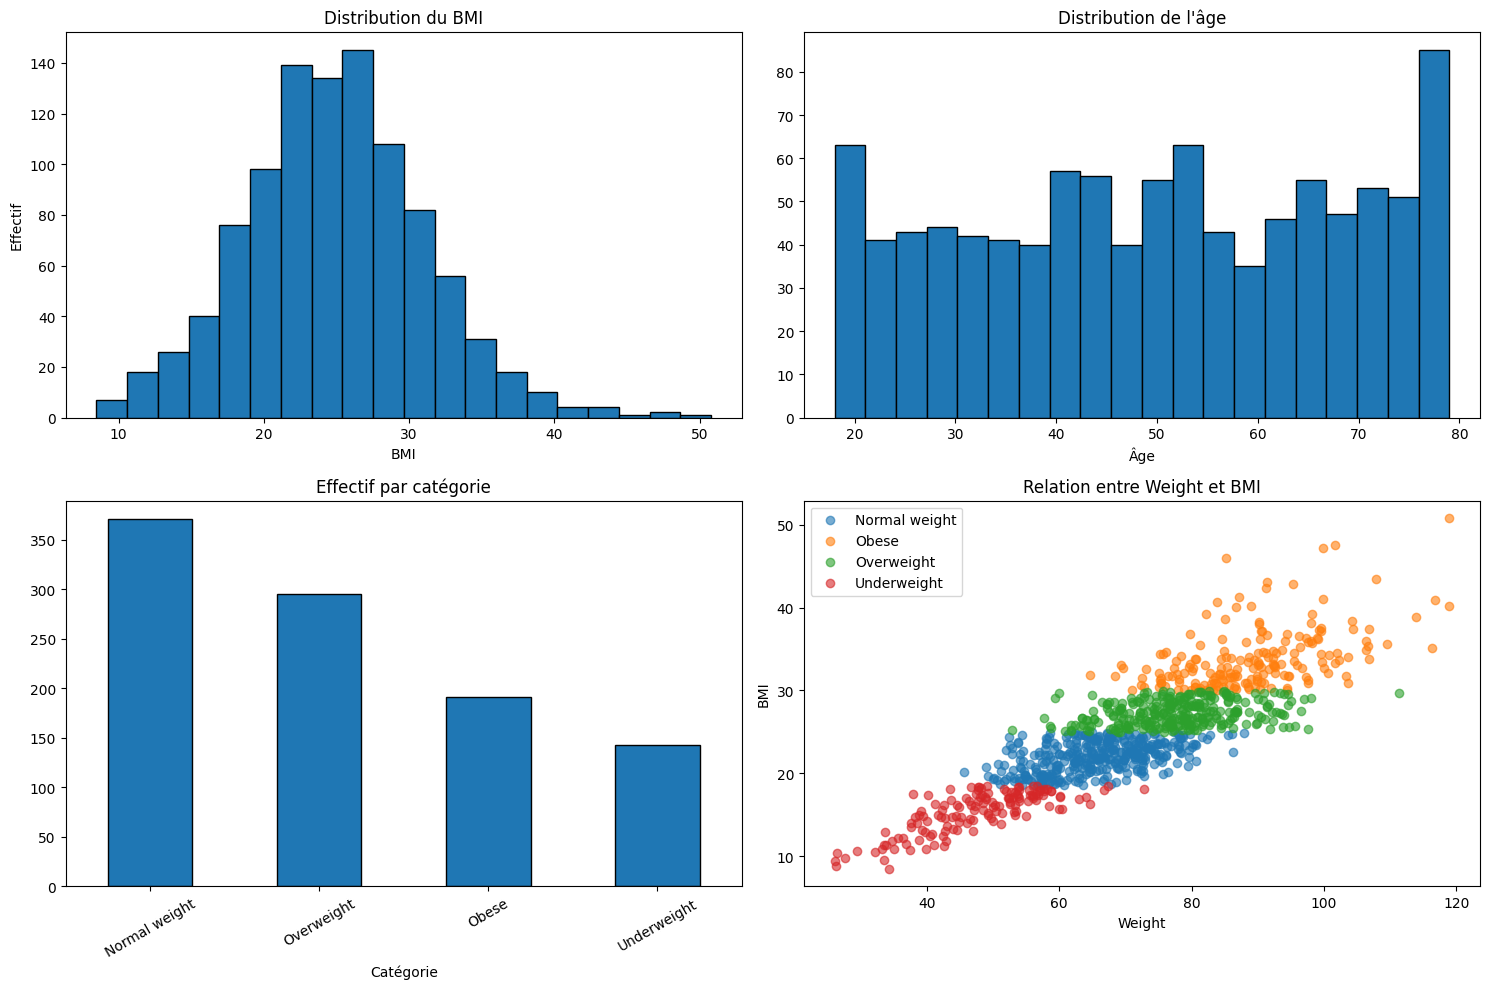

In [6]:
# Q1 — Visualisations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(df["BMI"], bins=20, edgecolor="black")
axes[0, 0].set_title("Distribution du BMI")
axes[0, 0].set_xlabel("BMI")
axes[0, 0].set_ylabel("Effectif")

axes[0, 1].hist(df["Age"], bins=20, edgecolor="black")
axes[0, 1].set_title("Distribution de l'âge")
axes[0, 1].set_xlabel("Âge")

order = df["ObesityCategory"].value_counts().index
df["ObesityCategory"].value_counts().reindex(order).plot(kind="bar", ax=axes[1, 0], edgecolor="black")
axes[1, 0].set_title("Effectif par catégorie")
axes[1, 0].set_xlabel("Catégorie")
axes[1, 0].tick_params(axis="x", rotation=30)

for category, group in df.groupby("ObesityCategory"):
    axes[1, 1].scatter(group["Weight"], group["BMI"], label=category, alpha=0.6)
axes[1, 1].set_title("Relation entre Weight et BMI")
axes[1, 1].set_xlabel("Weight")
axes[1, 1].set_ylabel("BMI")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Q1_visualisations.png", dpi=150)
plt.show()


## Q2 à Q6 — Apprentissage, tâche, métriques, cible et variable explicative

In [7]:
# Q2-Q6 — Définition du problème
TARGET = "ObesityCategory"
EXPLANATORY_VARIABLE = "BMI"

print("Type d'apprentissage : supervisé")
print("Tâche : classification supervisée multiclasse")
print("Variable cible :", TARGET)
print("Variable explicative principale :", EXPLANATORY_VARIABLE)
print("Classes :", df[TARGET].unique().tolist())
print("\nRemarque : BMI est directement lié à la définition de la cible. Les performances obtenues avec BMI doivent donc être interprétées comme la reproduction d'une règle de classification, et non comme une prédiction indépendante.")


Type d'apprentissage : supervisé
Tâche : classification supervisée multiclasse
Variable cible : ObesityCategory
Variable explicative principale : BMI
Classes : ['Normal weight', 'Obese', 'Overweight', 'Underweight']

Remarque : BMI est directement lié à la définition de la cible. Les performances obtenues avec BMI doivent donc être interprétées comme la reproduction d'une règle de classification, et non comme une prédiction indépendante.


## Q7 — Prétraitement et encodage

In [8]:
# Q7 — Encodage pour documenter le prétraitement
# BMI est déjà numérique et ne nécessite pas d'encodage.
# Les chaînes sont encodées uniquement dans une copie destinée à l'analyse.

encoded_df = df.copy()
encoded_df["Gender"] = encoded_df["Gender"].map({"Male": 0, "Female": 1})
category_mapping = {"Underweight": 0, "Normal weight": 1, "Overweight": 2, "Obese": 3}
encoded_df[TARGET] = encoded_df[TARGET].map(category_mapping)

print("Codage de Gender : Male=0, Female=1")
print("Codage de ObesityCategory :", category_mapping)
display(encoded_df.head())
print("\nValeurs manquantes après encodage :")
print(encoded_df.isna().sum())

encoded_df.to_csv(OUTPUT_DIR / "obesity_data_encoded.csv", index=False)


Codage de Gender : Male=0, Female=1
Codage de ObesityCategory : {'Underweight': 0, 'Normal weight': 1, 'Overweight': 2, 'Obese': 3}


,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory
0,56,0,173.575262,71.982051,23.891783,4,1
1,69,0,164.127306,89.959256,33.395209,2,3
2,46,1,168.072202,72.930629,25.817737,4,2
3,32,0,168.459633,84.886912,29.912247,3,2
4,60,0,183.568568,69.038945,20.487903,3,1



Valeurs manquantes après encodage :
Age                      0
Gender                   0
Height                   0
Weight                   0
BMI                      0
PhysicalActivityLevel    0
ObesityCategory          0
dtype: int64


## Q8 — Séparation des données

In [9]:
# Q8 — Construction des ensembles BMI et séparation 80/20
y = df[TARGET].copy()

# Modèle principal : BMI uniquement
X_bmi = df[[EXPLANATORY_VARIABLE]].copy()

# Analyse complémentaire : toutes les variables sauf BMI et la cible
X_without_bmi = pd.get_dummies(
    df.drop(columns=[TARGET, "BMI"]),
    columns=["Gender"],
    drop_first=False,
    dtype=float
)

X_bmi_train, X_bmi_test, y_train, y_test = train_test_split(
    X_bmi, y, test_size=0.20, random_state=42, stratify=y
)

X_no_bmi_train, X_no_bmi_test, _, _ = train_test_split(
    X_without_bmi, y, test_size=0.20, random_state=42, stratify=y
)

print("BMI uniquement :", X_bmi_train.shape, X_bmi_test.shape)
print("Variables sans BMI :", X_no_bmi_train.columns.tolist())
print("Sans BMI :", X_no_bmi_train.shape, X_no_bmi_test.shape)
print("\nRépartition des classes dans le train :")
print(y_train.value_counts())
print("\nRépartition des classes dans le test :")
print(y_test.value_counts())


BMI uniquement : (800, 1) (200, 1)
Variables sans BMI : ['Age', 'Height', 'Weight', 'PhysicalActivityLevel', 'Gender_Female', 'Gender_Male']
Sans BMI : (800, 6) (200, 6)

Répartition des classes dans le train :
ObesityCategory
Normal weight    297
Overweight       236
Obese            153
Underweight      114
Name: count, dtype: int64

Répartition des classes dans le test :
ObesityCategory
Normal weight    74
Overweight       59
Obese            38
Underweight      29
Name: count, dtype: int64


## Q9 à Q12 — Modèles CART avec Gini et entropie

In [11]:
# Fonction d'évaluation commune aux quatre modèles CART
def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)
    classes = model.classes_

    precision, recall, f1, support = precision_recall_fscore_support(
        y_test, predictions, labels=classes, zero_division=0
    )
    metrics = {
        "Modèle": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced accuracy": balanced_accuracy_score(y_test, predictions),
        "Precision macro": precision.mean(),
        "Recall macro": recall.mean(),
        "F1 macro": f1.mean(),
        "F1 pondéré": np.average(f1, weights=support),
        "Profondeur": model.get_depth(),
        "Feuilles": model.get_n_leaves(),
    }
    try:
        metrics["AUC-ROC OVR macro"] = roc_auc_score(
            y_test, probabilities, labels=classes, multi_class="ovr", average="macro"
        )
    except ValueError:
        metrics["AUC-ROC OVR macro"] = np.nan

    print(f"\n===== {model_name} =====")
    print(pd.Series(metrics).round(4))
    print("\nRapport de classification :")
    print(classification_report(y_test, predictions, zero_division=0))
    print("Matrice de confusion :")
    display(pd.DataFrame(confusion_matrix(y_test, predictions, labels=classes), index=classes, columns=classes))
    return model, metrics, predictions


In [12]:
# Q9-Q10 — Modèle 1 : CART avec Gini, BMI uniquement
model_gini_bmi = DecisionTreeClassifier(criterion="gini", random_state=42)
model_gini_bmi, result_gini_bmi, pred_gini_bmi = evaluate_classifier(
    model_gini_bmi, X_bmi_train, X_bmi_test, y_train, y_test, "Gini — BMI uniquement"
)



===== Gini — BMI uniquement =====
Modèle               Gini — BMI uniquement
Accuracy                               1.0
Balanced accuracy                      1.0
Precision macro                        1.0
Recall macro                           1.0
F1 macro                               1.0
F1 pondéré                             1.0
Profondeur                               2
Feuilles                                 4
AUC-ROC OVR macro                      1.0
dtype: object

Rapport de classification :
               precision    recall  f1-score   support

Normal weight       1.00      1.00      1.00        74
        Obese       1.00      1.00      1.00        38
   Overweight       1.00      1.00      1.00        59
  Underweight       1.00      1.00      1.00        29

     accuracy                           1.00       200
    macro avg       1.00      1.00      1.00       200
 weighted avg       1.00      1.00      1.00       200

Matrice de confusion :


,Normal weight,Obese,Overweight,Underweight
Normal weight,74,0,0,0
Obese,0,38,0,0
Overweight,0,0,59,0
Underweight,0,0,0,29


In [13]:
# Q9-Q10 — Analyse complémentaire : Gini, sans BMI
model_gini_no_bmi = DecisionTreeClassifier(criterion="gini", random_state=42)
model_gini_no_bmi, result_gini_no_bmi, pred_gini_no_bmi = evaluate_classifier(
    model_gini_no_bmi, X_no_bmi_train, X_no_bmi_test, y_train, y_test, "Gini — variables restantes sans BMI"
)



===== Gini — variables restantes sans BMI =====
Modèle               Gini — variables restantes sans BMI
Accuracy                                            0.92
Balanced accuracy                                0.91108
Precision macro                                 0.925911
Recall macro                                     0.91108
F1 macro                                         0.91776
F1 pondéré                                      0.919883
Profondeur                                            10
Feuilles                                              60
AUC-ROC OVR macro                               0.941223
dtype: object

Rapport de classification :
               precision    recall  f1-score   support

Normal weight       0.92      0.95      0.93        74
        Obese       0.92      0.92      0.92        38
   Overweight       0.90      0.92      0.91        59
  Underweight       0.96      0.86      0.91        29

     accuracy                           0.92       200
    ma

,Normal weight,Obese,Overweight,Underweight
Normal weight,70,0,3,1
Obese,0,35,3,0
Overweight,2,3,54,0
Underweight,4,0,0,25


In [14]:
# Q11-Q12 — Modèle 2 : CART avec entropie, BMI uniquement
model_entropy_bmi = DecisionTreeClassifier(criterion="entropy", random_state=42)
model_entropy_bmi, result_entropy_bmi, pred_entropy_bmi = evaluate_classifier(
    model_entropy_bmi, X_bmi_train, X_bmi_test, y_train, y_test, "Entropie — BMI uniquement"
)



===== Entropie — BMI uniquement =====
Modèle               Entropie — BMI uniquement
Accuracy                                   1.0
Balanced accuracy                          1.0
Precision macro                            1.0
Recall macro                               1.0
F1 macro                                   1.0
F1 pondéré                                 1.0
Profondeur                                   2
Feuilles                                     4
AUC-ROC OVR macro                          1.0
dtype: object

Rapport de classification :
               precision    recall  f1-score   support

Normal weight       1.00      1.00      1.00        74
        Obese       1.00      1.00      1.00        38
   Overweight       1.00      1.00      1.00        59
  Underweight       1.00      1.00      1.00        29

     accuracy                           1.00       200
    macro avg       1.00      1.00      1.00       200
 weighted avg       1.00      1.00      1.00       200

Matri

,Normal weight,Obese,Overweight,Underweight
Normal weight,74,0,0,0
Obese,0,38,0,0
Overweight,0,0,59,0
Underweight,0,0,0,29


In [15]:
# Q11-Q12 — Analyse complémentaire : entropie, sans BMI
model_entropy_no_bmi = DecisionTreeClassifier(criterion="entropy", random_state=42)
model_entropy_no_bmi, result_entropy_no_bmi, pred_entropy_no_bmi = evaluate_classifier(
    model_entropy_no_bmi, X_no_bmi_train, X_no_bmi_test, y_train, y_test, "Entropie — variables restantes sans BMI"
)



===== Entropie — variables restantes sans BMI =====
Modèle               Entropie — variables restantes sans BMI
Accuracy                                               0.945
Balanced accuracy                                   0.949776
Precision macro                                     0.945793
Recall macro                                        0.949776
F1 macro                                            0.947683
F1 pondéré                                          0.944837
Profondeur                                                11
Feuilles                                                  52
AUC-ROC OVR macro                                    0.96514
dtype: object

Rapport de classification :
               precision    recall  f1-score   support

Normal weight       0.94      0.92      0.93        74
        Obese       0.97      1.00      0.99        38
   Overweight       0.93      0.95      0.94        59
  Underweight       0.93      0.93      0.93        29

     accuracy    

,Normal weight,Obese,Overweight,Underweight
Normal weight,68,0,4,2
Obese,0,38,0,0
Overweight,2,1,56,0
Underweight,2,0,0,27


## Q13 — Affichage des arbres

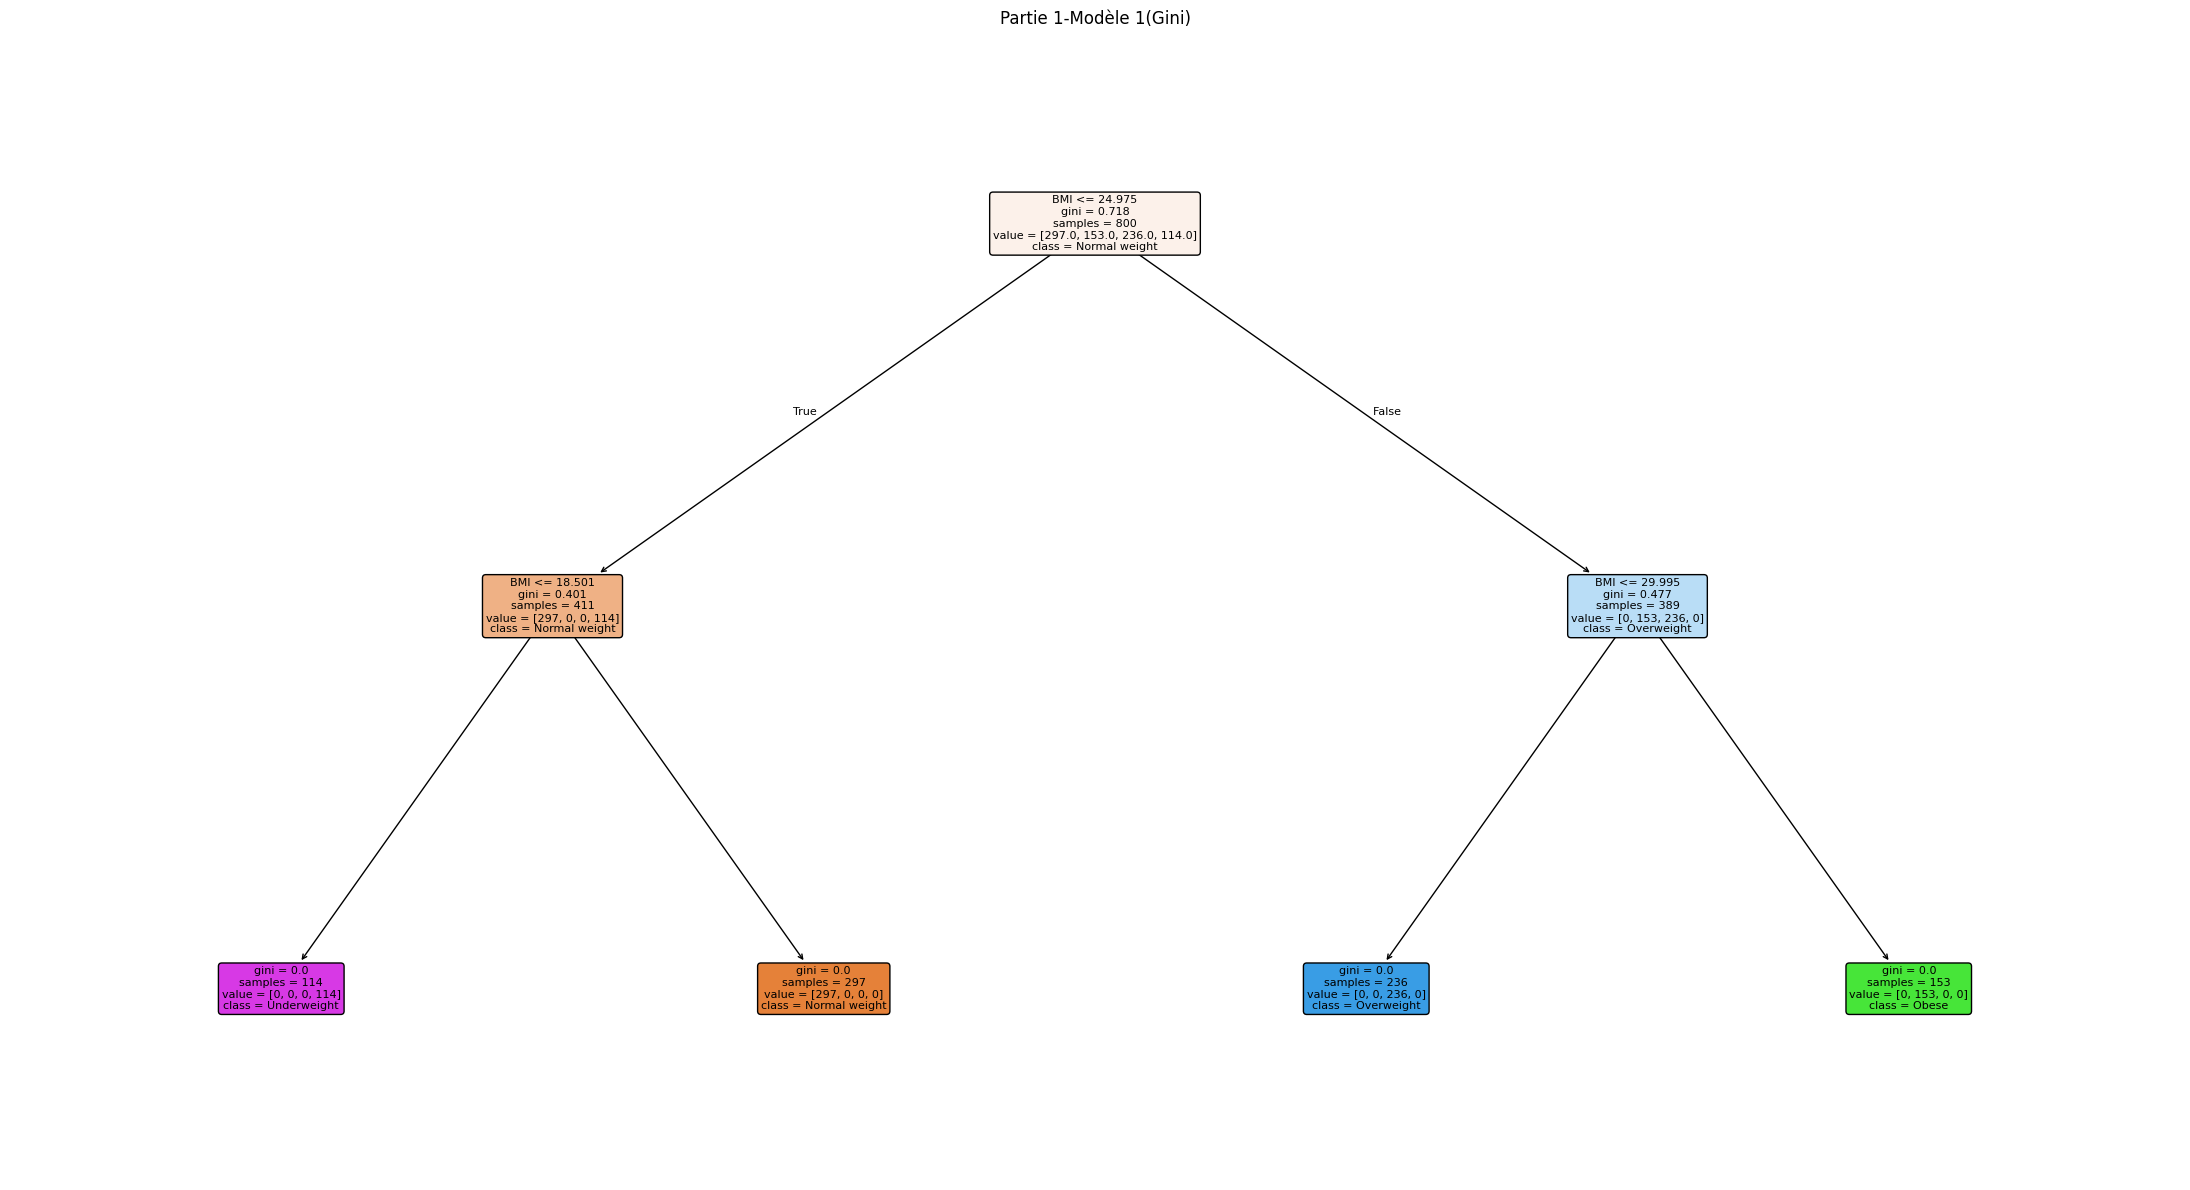

Figure sauvegardée : /content/drive/MyDrive/Modélisation/resultats_TP/Q13_gini_bmi.png


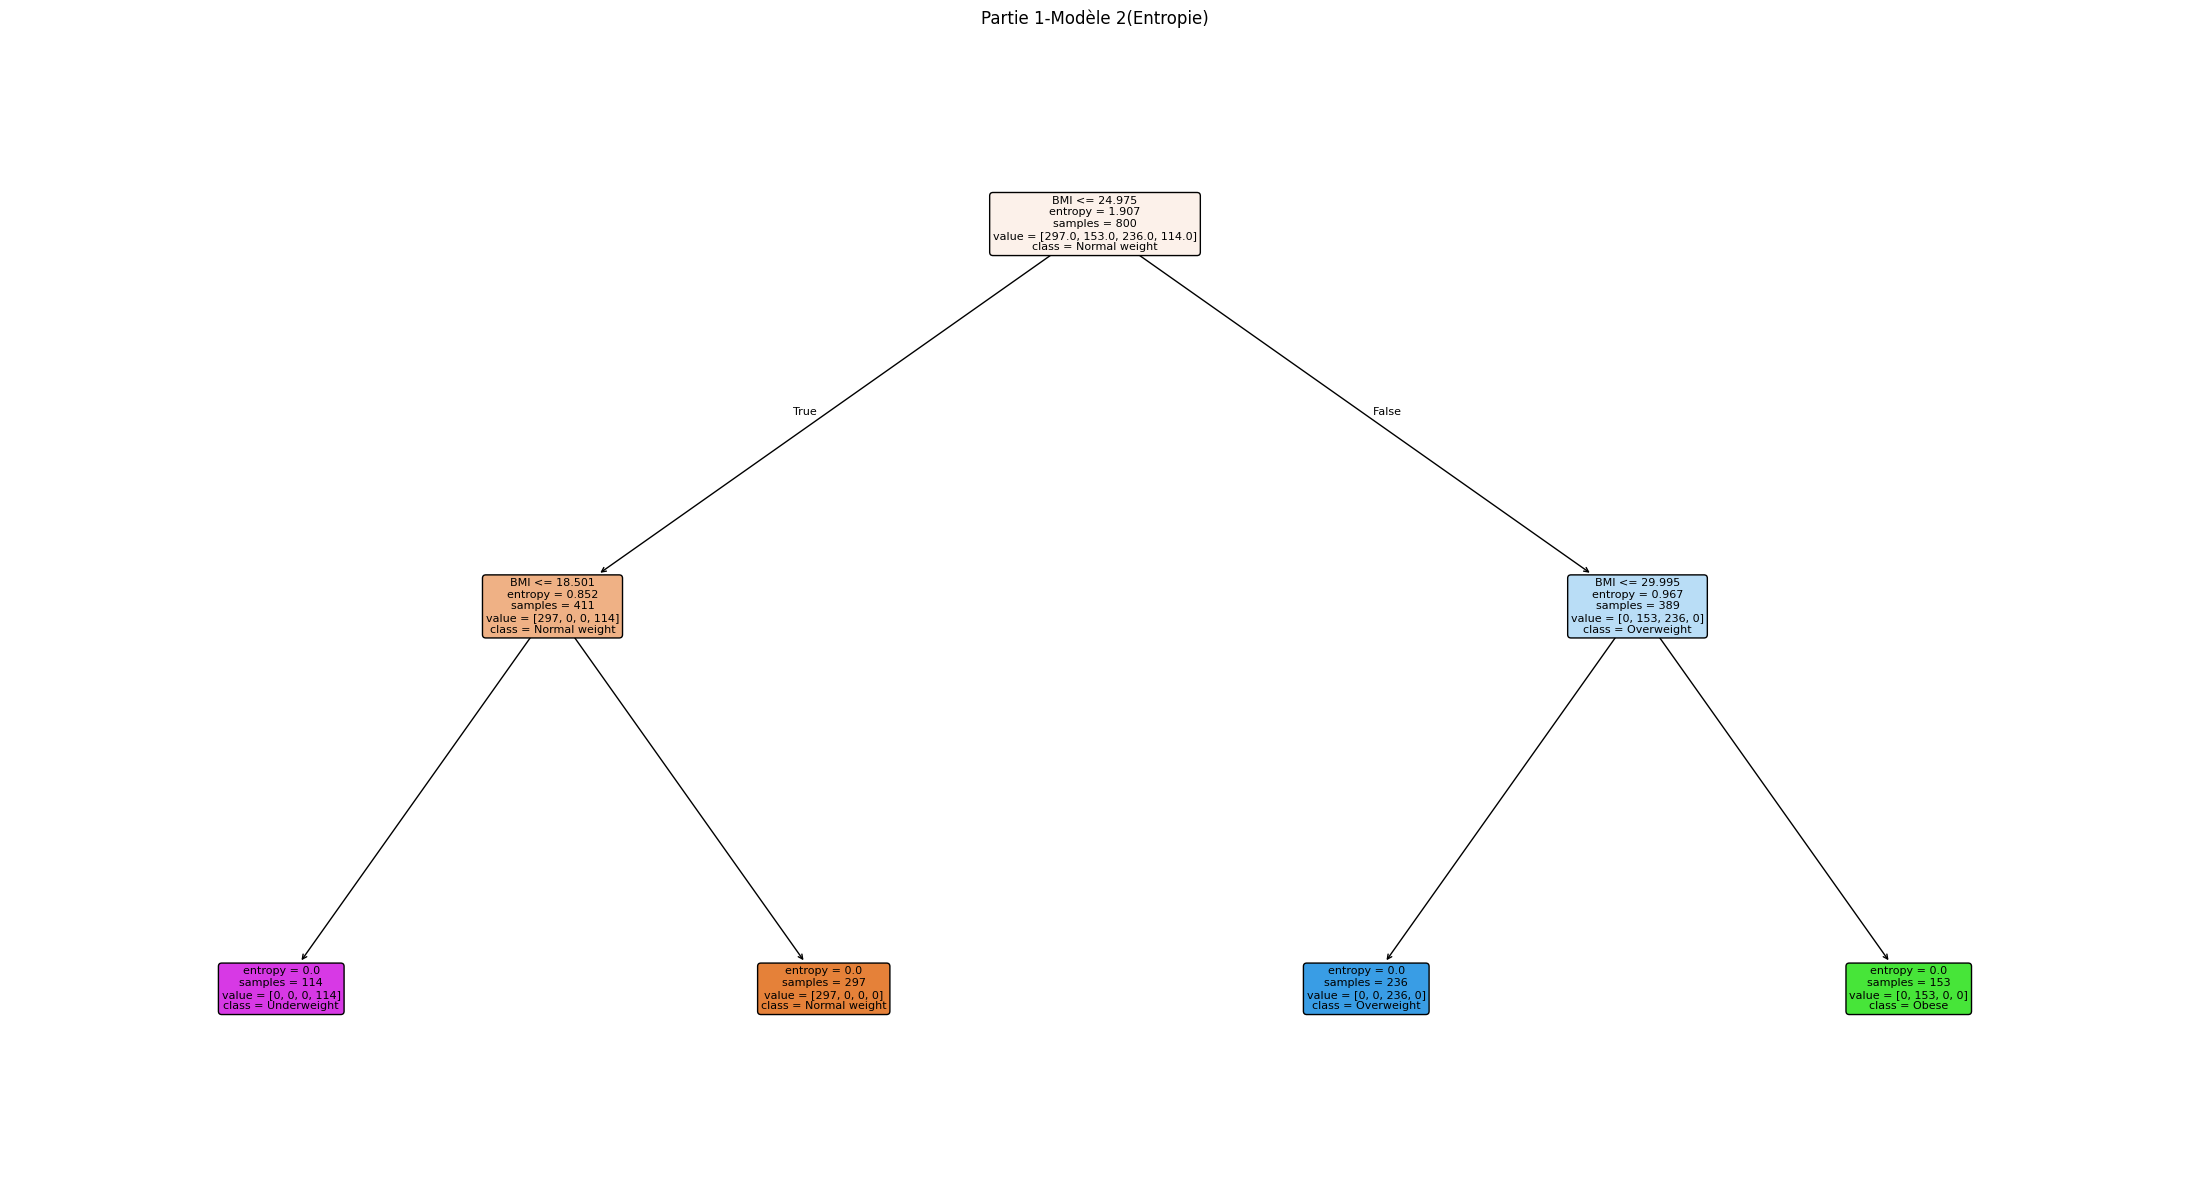

Figure sauvegardée : /content/drive/MyDrive/Modélisation/resultats_TP/Q13_entropy_bmi.png


In [19]:
# Q13 — Fonction de visualisation d'un arbre
def save_tree_plot(model, feature_names, output_name, title):
    plt.figure(figsize=(22, 12))
    plot_tree(
        model, feature_names=list(feature_names), class_names=[str(c) for c in model.classes_],
        filled=True, rounded=True, fontsize=8
    )
    plt.title(title)
    plt.tight_layout()
    path = OUTPUT_DIR / output_name
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure sauvegardée :", path)

save_tree_plot(model_gini_bmi, X_bmi.columns, "Q13_gini_bmi.png", "Partie 1-Modèle 1(Gini)")
save_tree_plot(model_entropy_bmi, X_bmi.columns, "Q13_entropy_bmi.png", "Partie 1-Modèle 2(Entropie)")


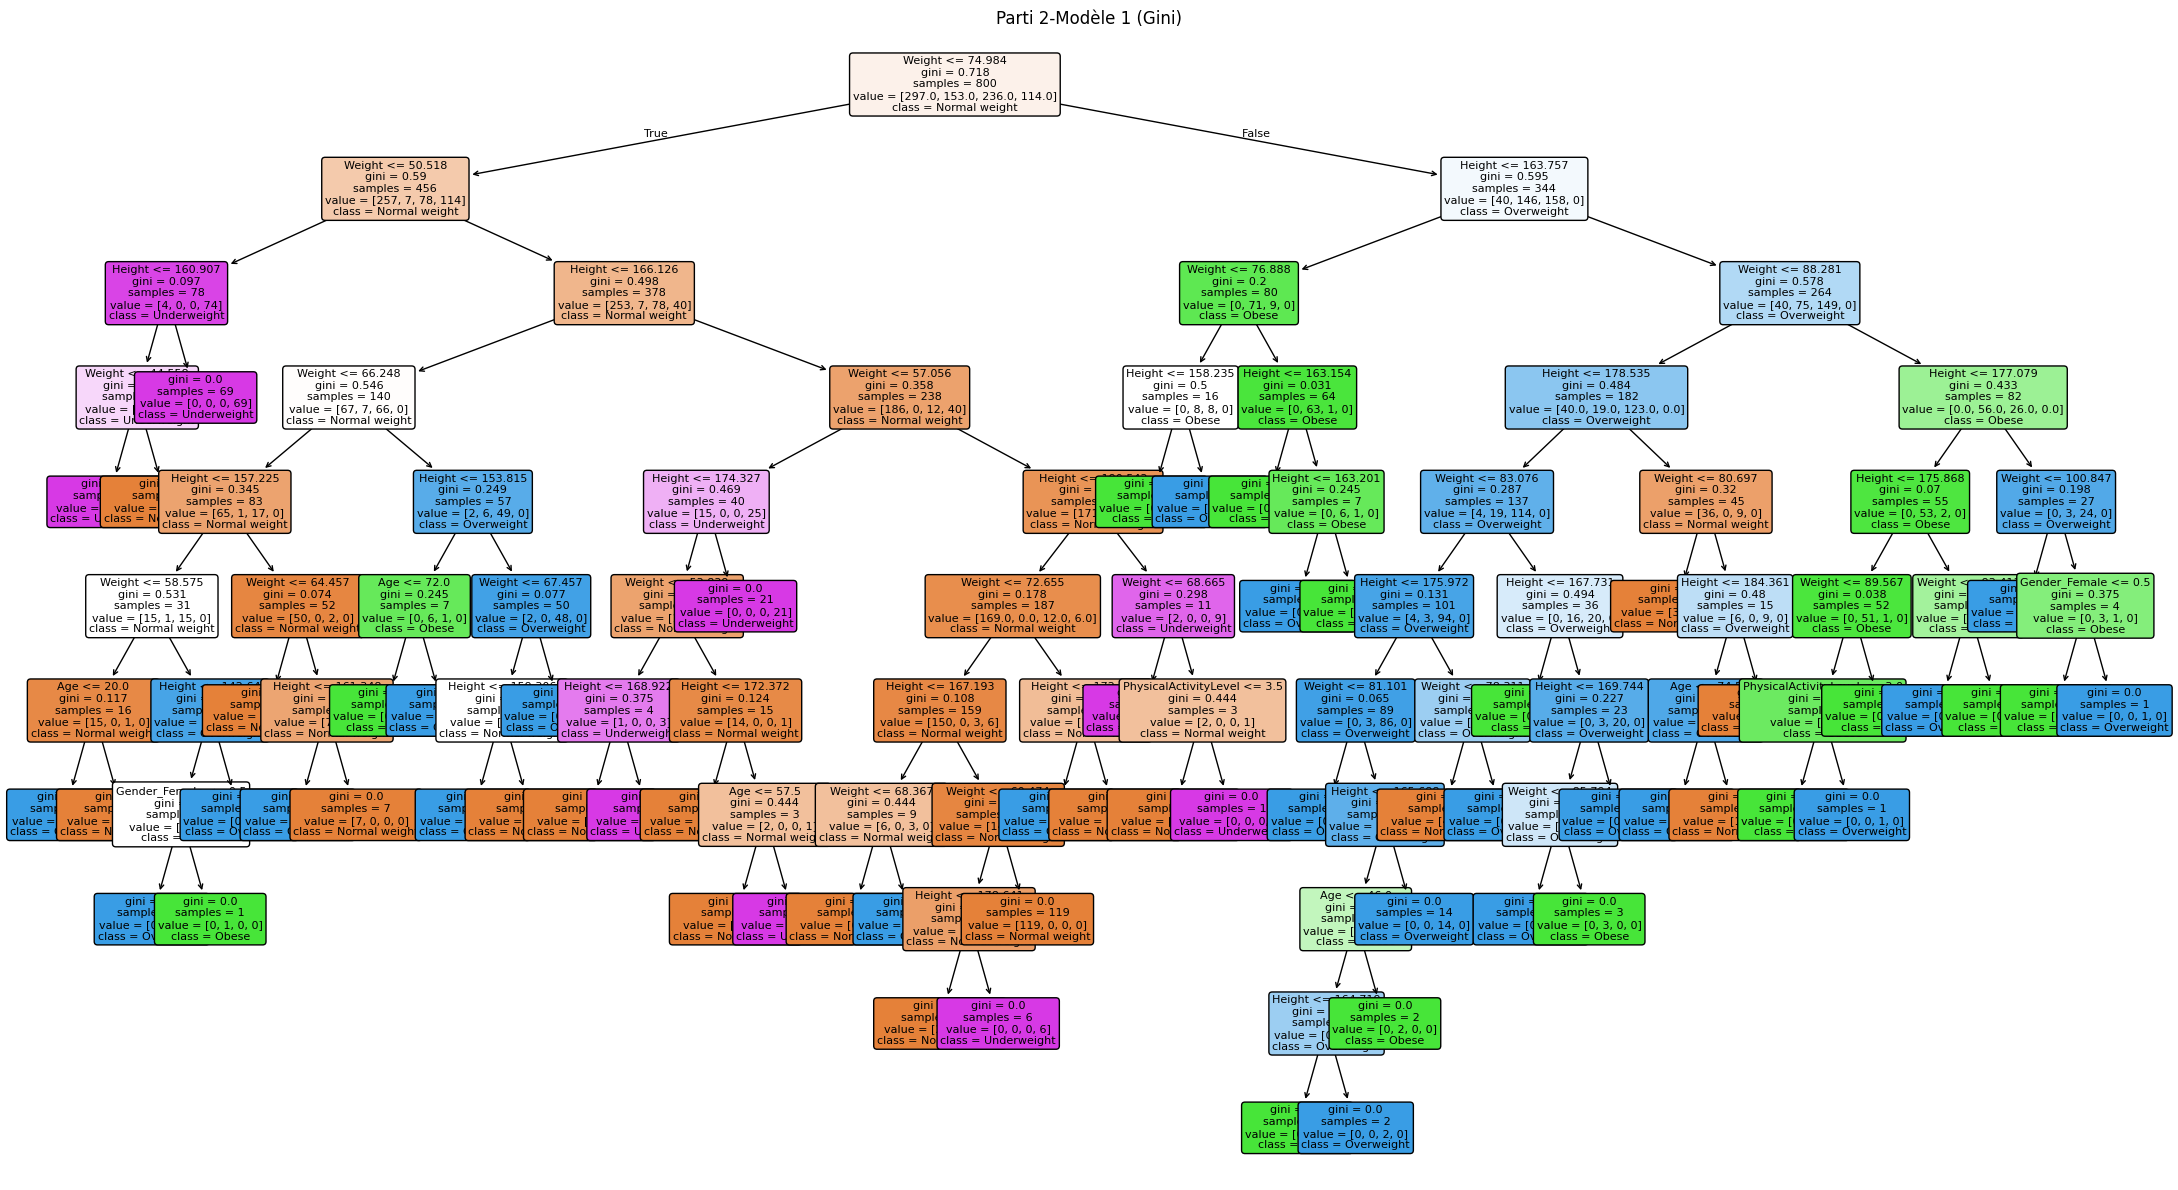

Figure sauvegardée : /content/drive/MyDrive/Modélisation/resultats_TP/Q13_gini_sans_bmi.png


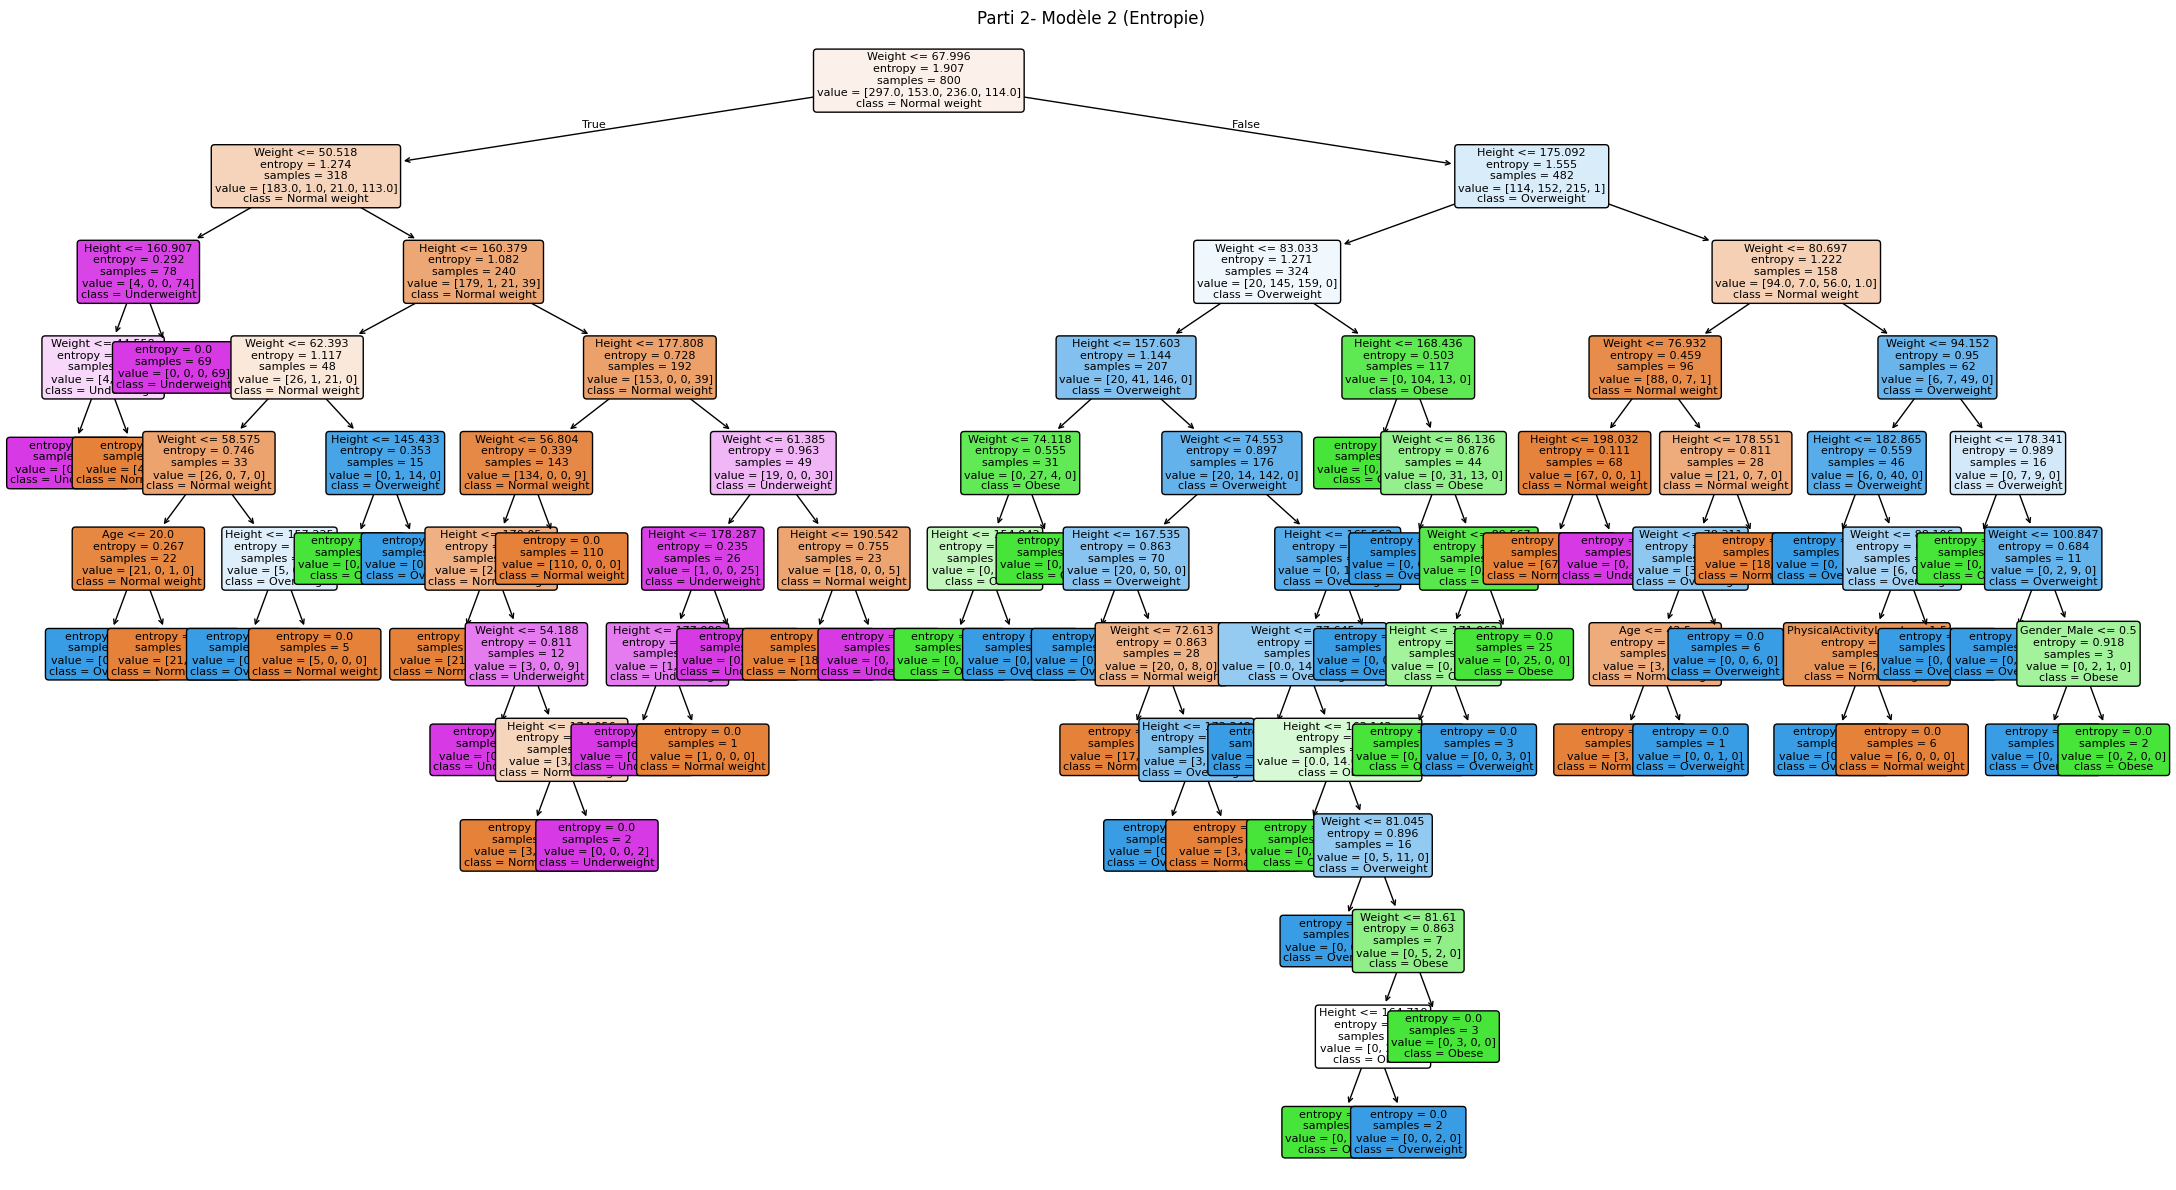

Figure sauvegardée : /content/drive/MyDrive/Modélisation/resultats_TP/Q13_entropy_sans_bmi.png


In [18]:
# Q13 — Affichage des arbres sans BMI
save_tree_plot(model_gini_no_bmi, X_no_bmi_train.columns, "Q13_gini_sans_bmi.png", "Parti 2-Modèle 1 (Gini)")
save_tree_plot(model_entropy_no_bmi, X_no_bmi_train.columns, "Q13_entropy_sans_bmi.png", "Parti 2- Modèle 2 (Entropie)")


## Q14 — Interprétation et comparaison

In [20]:
# Q14 — Comparaison des quatre modèles
comparison = pd.DataFrame([
    result_gini_bmi, result_gini_no_bmi,
    result_entropy_bmi, result_entropy_no_bmi
]).set_index("Modèle")

print("Tableau comparatif :")
display(comparison.round(4))
comparison.round(4).to_csv(OUTPUT_DIR / "Q14_comparaison_modeles.csv")

print("Interprétation :")
print("- Avec BMI, les arbres sont généralement simples car BMI est directement lié à la cible.")
print("- Sans BMI, le modèle doit reconstruire indirectement cette relation à partir des variables restantes.")
print("- Les résultats ne doivent pas être interprétés comme une preuve de généralisation indépendante, car la cible est liée au BMI.")


Tableau comparatif :


,Accuracy,Balanced accuracy,Precision macro,Recall macro,F1 macro,F1 pondéré,Profondeur,Feuilles,AUC-ROC OVR macro
Modèle,,,,,,,,,
Gini — BMI uniquement,1.000,1.0000,1.0000,1.0000,1.0000,1.0000,2,4,1.0000
Gini — variables restantes sans BMI,0.920,0.9111,0.9259,0.9111,0.9178,0.9199,10,60,0.9412
Entropie — BMI uniquement,1.000,1.0000,1.0000,1.0000,1.0000,1.0000,2,4,1.0000
Entropie — variables restantes sans BMI,0.945,0.9498,0.9458,0.9498,0.9477,0.9448,11,52,0.9651


Interprétation :
- Avec BMI, les arbres sont généralement simples car BMI est directement lié à la cible.
- Sans BMI, le modèle doit reconstruire indirectement cette relation à partir des variables restantes.
- Les résultats ne doivent pas être interprétés comme une preuve de généralisation indépendante, car la cible est liée au BMI.


## Section 2 — Q15 à Q19 : arbre ID3

In [21]:
# Q15 — Chargement du jeu binaire
binary = pd.read_csv(BINARY_FILE).astype(int)
TARGET_BINARY = "ObesityCategory"
FEATURES_BINARY = [c for c in binary.columns if c != TARGET_BINARY]

print("Dimensions :", binary.shape)
display(binary)
print("Répartition de la cible :")
print(binary[TARGET_BINARY].value_counts())


Dimensions : (8, 7)


,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory
0,0,0,1,0,0,1,0
1,1,1,0,1,1,0,1
2,0,1,1,1,1,0,1
3,1,0,1,1,1,0,1
4,1,1,0,0,0,1,0
5,0,0,0,1,1,1,1
6,0,1,1,0,0,1,0
7,1,0,0,1,1,0,1


Répartition de la cible :
ObesityCategory
1    5
0    3
Name: count, dtype: int64


In [22]:
# Q16 — Fonction Entropie
def entropy(values):
    counts = pd.Series(values).value_counts()
    total = len(values)
    return -sum((count / total) * log2(count / total) for count in counts if count > 0)

print("Entropie initiale :", round(entropy(binary[TARGET_BINARY]), 6))


Entropie initiale : 0.954434


In [23]:
# Q16 — Fonction Information Gain
def information_gain(dataframe, feature, target):
    parent_entropy = entropy(dataframe[target])
    total = len(dataframe)
    remainder = 0
    for _, group in dataframe.groupby(feature, sort=False):
        remainder += (len(group) / total) * entropy(group[target])
    return parent_entropy - remainder

ig_table = pd.DataFrame([
    {"Attribut": feature, "Information_Gain": information_gain(binary, feature, TARGET_BINARY)}
    for feature in FEATURES_BINARY
]).sort_values("Information_Gain", ascending=False)

print("Gains d'information :")
display(ig_table.round(6))


Gains d'information :


,Attribut,Information_Gain
4,BMI,0.954434
3,Weight,0.954434
5,PhysicalActivityLevel,0.548795
0,Age,0.048795
1,Gender,0.048795
2,Height,0.048795


In [24]:
# Q17 — Construction récursive de l'arbre ID3 avec priorité à BMI en cas d'égalité
def build_id3_tree(dataframe, available_features, target):
    if dataframe[target].nunique() == 1:
        return {"type": "leaf", "class": int(dataframe[target].iloc[0]), "n": len(dataframe)}
    if not available_features:
        return {"type": "leaf", "class": int(dataframe[target].mode().iloc[0]), "n": len(dataframe)}

    scores = {feature: information_gain(dataframe, feature, target) for feature in available_features}
    best_score = max(scores.values())
    best_features = [feature for feature, score in scores.items() if np.isclose(score, best_score)]
    best_feature = "BMI" if "BMI" in best_features else best_features[0]

    node = {"type": "node", "attribute": best_feature, "score": scores[best_feature], "n": len(dataframe), "children": {}}
    remaining = [feature for feature in available_features if feature != best_feature]
    for value, subset in dataframe.groupby(best_feature, sort=True):
        node["children"][int(value)] = build_id3_tree(subset, remaining, target)
    return node

arbre_id3 = build_id3_tree(binary, FEATURES_BINARY, TARGET_BINARY)
print("Racine ID3 :", arbre_id3.get("attribute"))


Racine ID3 : BMI


In [25]:
# Q18-Q19 — Affichage et statistiques de l'arbre ID3
def print_tree(tree, indentation="", score_name="score"):
    if tree["type"] == "leaf":
        print(f"{indentation}Feuille : classe={tree['class']} (n={tree['n']})")
        return
    print(f"{indentation}Nœud : {tree['attribute']} | {score_name}={tree['score']:.6f} | n={tree['n']}")
    for value, child in tree["children"].items():
        print(f"{indentation}  Si {tree['attribute']} == {value} :")
        print_tree(child, indentation + "    ", score_name)

def tree_statistics(tree):
    if tree["type"] == "leaf":
        return 0, 1
    depths, leaves = [], 0
    for child in tree["children"].values():
        depth, n_leaves = tree_statistics(child)
        depths.append(depth)
        leaves += n_leaves
    return 1 + max(depths), leaves

print_tree(arbre_id3, score_name="Information Gain")
depth_id3, leaves_id3 = tree_statistics(arbre_id3)
print("Profondeur maximale ID3 :", depth_id3)
print("Nombre de feuilles ID3 :", leaves_id3)


Nœud : BMI | Information Gain=0.954434 | n=8
  Si BMI == 0 :
    Feuille : classe=0 (n=3)
  Si BMI == 1 :
    Feuille : classe=1 (n=5)
Profondeur maximale ID3 : 1
Nombre de feuilles ID3 : 2


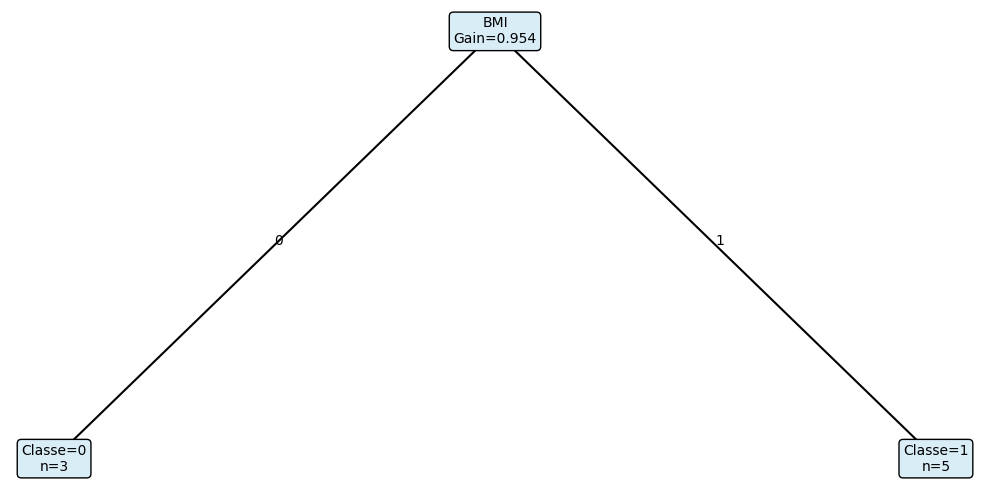

In [26]:
# Q17-Q19 — Visualisation et export de l'arbre ID3
def draw_custom_tree(tree, output_path, score_name="score", color="#d9edf7"):
    positions, labels, edges = {}, {}, []
    counter = [0]
    def visit(node, depth=0, parent=None, edge_label=""):
        node_id = counter[0]; counter[0] += 1
        if node["type"] == "leaf":
            labels[node_id] = f"Classe={node['class']}\nn={node['n']}"
        else:
            labels[node_id] = f"{node['attribute']}\n{score_name}={node['score']:.3f}"
        children = list(node.get("children", {}).items())
        if children:
            child_x = [visit(child, depth + 1, node_id, str(value)) for value, child in children]
            positions[node_id] = (np.mean(child_x), -depth)
        else:
            positions[node_id] = (node_id, -depth)
        if parent is not None:
            edges.append((parent, node_id, edge_label))
        return positions[node_id][0]
    visit(tree)
    fig, ax = plt.subplots(figsize=(10, 5))
    for parent, child, label in edges:
        x1, y1 = positions[parent]; x2, y2 = positions[child]
        ax.plot([x1, x2], [y1, y2], "k-")
        ax.text((x1+x2)/2, (y1+y2)/2, label)
    for node_id, text in labels.items():
        x, y = positions[node_id]
        ax.text(x, y, text, ha="center", va="center", bbox=dict(boxstyle="round", fc=color))
    ax.axis("off"); fig.tight_layout(); fig.savefig(output_path, dpi=150); plt.show()

draw_custom_tree(arbre_id3, OUTPUT_DIR / "Q17_Q19_arbre_ID3.png", "Gain")
with open(OUTPUT_DIR / "Q17_Q19_structure_ID3.txt", "w", encoding="utf-8") as f:
    with redirect_stdout(f):
        print_tree(arbre_id3, score_name="Information Gain")


## Section 3 — Q20 : arbre C4.5

In [27]:
# Q20 — Fonctions Split Information et Gain Ratio
def split_information(values):
    return entropy(values)

def gain_ratio(dataframe, feature, target):
    split_info = split_information(dataframe[feature])
    if np.isclose(split_info, 0):
        return 0.0
    return information_gain(dataframe, feature, target) / split_info

ratio_table = pd.DataFrame([
    {
        "Attribut": feature,
        "Information_Gain": information_gain(binary, feature, TARGET_BINARY),
        "Split_Information": split_information(binary[feature]),
        "Gain_Ratio": gain_ratio(binary, feature, TARGET_BINARY)
    }
    for feature in FEATURES_BINARY
]).sort_values("Gain_Ratio", ascending=False)

print("Scores C4.5 :")
display(ratio_table.round(6))


Scores C4.5 :


,Attribut,Information_Gain,Split_Information,Gain_Ratio
4,BMI,0.954434,0.954434,1.000000
3,Weight,0.954434,0.954434,1.000000
5,PhysicalActivityLevel,0.548795,1.000000,0.548795
0,Age,0.048795,1.000000,0.048795
1,Gender,0.048795,1.000000,0.048795
2,Height,0.048795,1.000000,0.048795


In [28]:
# Q20 — Construction récursive de l'arbre C4.5 avec priorité à BMI
def build_c45_tree(dataframe, available_features, target):
    if dataframe[target].nunique() == 1:
        return {"type": "leaf", "class": int(dataframe[target].iloc[0]), "n": len(dataframe)}
    if not available_features:
        return {"type": "leaf", "class": int(dataframe[target].mode().iloc[0]), "n": len(dataframe)}

    scores = {feature: gain_ratio(dataframe, feature, target) for feature in available_features}
    best_score = max(scores.values())
    best_features = [feature for feature, score in scores.items() if np.isclose(score, best_score)]
    best_feature = "BMI" if "BMI" in best_features else best_features[0]

    node = {"type": "node", "attribute": best_feature, "score": scores[best_feature], "n": len(dataframe), "children": {}}
    remaining = [feature for feature in available_features if feature != best_feature]
    for value, subset in dataframe.groupby(best_feature, sort=True):
        node["children"][int(value)] = build_c45_tree(subset, remaining, target)
    return node

arbre_c45 = build_c45_tree(binary, FEATURES_BINARY, TARGET_BINARY)
print("Racine C4.5 :", arbre_c45.get("attribute"))


Racine C4.5 : BMI


Nœud : BMI | Gain Ratio=1.000000 | n=8
  Si BMI == 0 :
    Feuille : classe=0 (n=3)
  Si BMI == 1 :
    Feuille : classe=1 (n=5)
Profondeur maximale C4.5 : 1
Nombre de feuilles C4.5 : 2


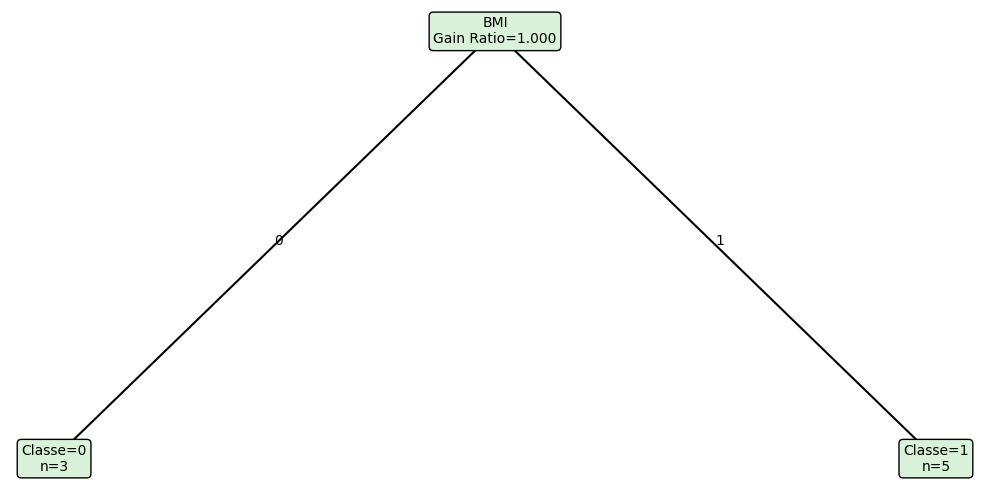

In [29]:
# Q20 — Affichage, statistiques, visualisation et export C4.5
print_tree(arbre_c45, score_name="Gain Ratio")
depth_c45, leaves_c45 = tree_statistics(arbre_c45)
print("Profondeur maximale C4.5 :", depth_c45)
print("Nombre de feuilles C4.5 :", leaves_c45)

draw_custom_tree(arbre_c45, OUTPUT_DIR / "Q20_arbre_C45.png", "Gain Ratio", "#d9f2d9")
ratio_table.round(6).to_csv(OUTPUT_DIR / "Q20_scores_C45.csv", index=False)
with open(OUTPUT_DIR / "Q20_structure_C45.txt", "w", encoding="utf-8") as f:
    with redirect_stdout(f):
        print_tree(arbre_c45, score_name="Gain Ratio")


## Export final

Les tableaux, figures et structures d'arbres sont enregistrés dans :

```text
/content/drive/MyDrive/Modélisation/resultats_TP/
```

**Interprétation attendue :** avec le jeu binaire, `BMI` et `Weight` peuvent être ex æquo. Le code donne explicitement la priorité à `BMI`, conformément au choix méthodologique du rapport.